In [1]:
import pandas as pd
import numpy as np
import os
#import geopandas as gpd
from dataretrieval import nwis, waterdata
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
sites_dict = {
    'James River at Scottsville, VA': '02029000',
    'Mechums River Near White Hall, VA': '02031000',
    'Moormans River Near Free Union, VA': '02032250',
    'N F Rivanna River Near Earlysville, VA': '02032640',
    'S F Rivanna River Near Charlottesville, VA': '02032515',
}

site_ids = list(sites_dict.values())

In [15]:
data = nwis.get_discharge_measurements(sites=site_ids)

In [19]:
data[1]

NWIS_Metadata(url=https://waterdata.usgs.gov/blog/wdfn-field-measurements/)

## Possible project ideas: 
1. use historical waterflow measurements and precipitation data to forecast flooding risk for central virginia
2. use HCP data to investigate connectivity changes over time during rs-fMRI

In [1]:
discharge, metadata = waterdata.get_daily(
    monitoring_location_id='USGS-02034000', 
    parameter_code='00060',  # Discharge
    time='1980-01-01/2024-12-30'
)
discharge['date'] = discharge['time']
discharge.set_index('date', inplace=True)

NameError: name 'waterdata' is not defined

In [5]:
discharge.head()

,geometry,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified,daily_id
date,,,,,,,,,,,,
1980-01-01,POINT (-78.26584 37.85792),186bd8942ca64b53874f2265ae40881f,USGS-02034000,00060,00003,1980-01-01,561.0,ft^3/s,Approved,None,2025-03-11 21:54:58.877607+00:00,278da8be-234b-4903-9225-99e4d5e2f9ab
1980-01-02,POINT (-78.26584 37.85792),186bd8942ca64b53874f2265ae40881f,USGS-02034000,00060,00003,1980-01-02,554.0,ft^3/s,Approved,None,2025-03-11 21:54:58.877607+00:00,1b408dc8-ec6e-4fad-a886-0de7f80751a9
1980-01-03,POINT (-78.26584 37.85792),186bd8942ca64b53874f2265ae40881f,USGS-02034000,00060,00003,1980-01-03,536.0,ft^3/s,Approved,None,2025-03-11 21:54:58.877607+00:00,25582fd6-ac63-4ed7-bbec-48579a5c194a
1980-01-04,POINT (-78.26584 37.85792),186bd8942ca64b53874f2265ae40881f,USGS-02034000,00060,00003,1980-01-04,530.0,ft^3/s,Approved,None,2025-03-11 21:54:58.877607+00:00,81c3b17e-8399-4608-a14c-619a099add17
1980-01-05,POINT (-78.26584 37.85792),186bd8942ca64b53874f2265ae40881f,USGS-02034000,00060,00003,1980-01-05,599.0,ft^3/s,Approved,None,2025-03-11 21:54:58.877607+00:00,521aa538-6ae2-44b4-8046-9ce4306e0463


In [27]:
date_ranges = [
    ('2007-10-01', '2010-06-27'),
    ('2010-06-27', '2013-03-23'),
    ('2013-03-23', '2015-12-18'),
    ('2015-12-18', '2018-09-13'),
    ('2018-09-13', '2021-06-09'),
    ('2021-06-09', '2024-03-05'),
    ('2024-03-05', '2024-12-30'),
]

frames = []
for start, end in date_ranges:
    df_chunk, _ = waterdata.get_continuous(
        monitoring_location_id='USGS-02034000',
        parameter_code='00065',
        time=f'{start}/{end}'
    )
    frames.append(df_chunk)

# Combine, drop duplicates at chunk boundaries, and resample to daily
gage_combined = pd.concat(frames)
gage_combined = gage_combined.drop_duplicates(subset='time')

# Resample to daily average
gage_combined['date'] = pd.to_datetime(gage_combined['time']).dt.date
gage_daily = (
    gage_combined
    .groupby('date')['value']
    .mean()
    .reset_index()
    .rename(columns={'value': 'gage_height_ft'})
)

print(gage_daily.head())
print(f"Date range: {gage_daily['date'].min()} to {gage_daily['date'].max()}")
print(f"Total days: {len(gage_daily)}")

         date  gage_height_ft
0  2007-10-01        2.151711
1  2007-10-02        2.146250
2  2007-10-03        2.140521
3  2007-10-04        2.150000
4  2007-10-05        2.150937
Date range: 2007-10-01 to 2024-12-30
Total days: 6290


In [25]:
gage['value'].describe()

count    93413.000000
mean         3.329748
std          1.356651
min          2.050000
25%          2.610000
50%          3.040000
75%          3.680000
max         23.520000
Name: value, dtype: float64

In [36]:
from dataretrieval import nwis

# Retrieve daily discharge data
discharge = nwis.get_dv(
    sites="10251290",
    parameterCd="00060",        
    start="2010-01-01",
    end="2026-04-01"
)
# Data returns as pandas DataFrame
df = discharge[0]
df.index = df.index.tz_localize(None).normalize()

In [58]:
foo = pd.read_csv('items.csv')
foo.head()

,id,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified
0,46228e5b-3a96-464e-b957-77d244f7fbe3,186bd8942ca64b53874f2265ae40881f,USGS-02034000,60,3,2024-12-31,965.0,ft^3/s,Provisional,NaN,2025-07-08 18:45:13.116670+00:00
1,c06d609f-6bcf-4b3f-856d-4be66babe184,186bd8942ca64b53874f2265ae40881f,USGS-02034000,60,3,2024-12-30,1210.0,ft^3/s,Provisional,NaN,2025-07-08 18:45:13.116670+00:00
2,ec096a22-b579-4764-9377-e3f61f7188ff,186bd8942ca64b53874f2265ae40881f,USGS-02034000,60,3,2024-12-29,1010.0,ft^3/s,Provisional,NaN,2025-07-08 18:45:13.116670+00:00
3,18c71c3c-ec6b-4759-b2ec-52faf3d1d674,186bd8942ca64b53874f2265ae40881f,USGS-02034000,60,3,2024-12-28,334.0,ft^3/s,Provisional,NaN,2025-07-08 18:45:13.116670+00:00
4,535dc84a-a7d4-4b89-8eca-f411a8050690,186bd8942ca64b53874f2265ae40881f,USGS-02034000,60,3,2024-12-27,281.0,ft^3/s,Provisional,NaN,2025-07-08 18:45:13.116670+00:00


In [30]:
df.tail()

,site_no,00060_Mean,00060_Mean_cd
datetime,,,
2026-03-28,10251290,0.05,"P, e"
2026-03-29,10251290,0.05,"P, e"
2026-03-30,10251290,0.05,"P, e"
2026-03-31,10251290,0.05,"P, e"
2026-04-01,10251290,0.05,"P, e"


In [16]:
daymet = pd.read_csv('11391_lat_37.8578_lon_-78.2661_2026-04-13_220703.csv', skiprows=6)
daymet['date'] = pd.to_datetime(daymet['year'], format='%Y') + pd.to_timedelta(daymet['yday'] - 1, unit='D')
daymet.set_index('date', inplace=True)
#daymet['time'] = daymet.index.date
daymet.head()

,year,yday,prcp (mm/day)
date,,,
1980-01-01,1980,1,0.00
1980-01-02,1980,2,0.00
1980-01-03,1980,3,0.00
1980-01-04,1980,4,18.33
1980-01-05,1980,5,10.38


In [42]:
daymet.tail()

,year,yday,prcp (mm/day)
date,,,
2024-12-26,2024,361,0.00
2024-12-27,2024,362,6.11
2024-12-28,2024,363,15.02
2024-12-29,2024,364,2.33
2024-12-30,2024,365,0.00


In [50]:
merged = discharge.join(daymet)
merged = merged[['value', 'prcp (mm/day)']]
merged = merged.rename(columns={'value': 'discharge', 'prcp (mm/day)': 'precipitation'})
merged = merged.ffill()
df = merged.copy()

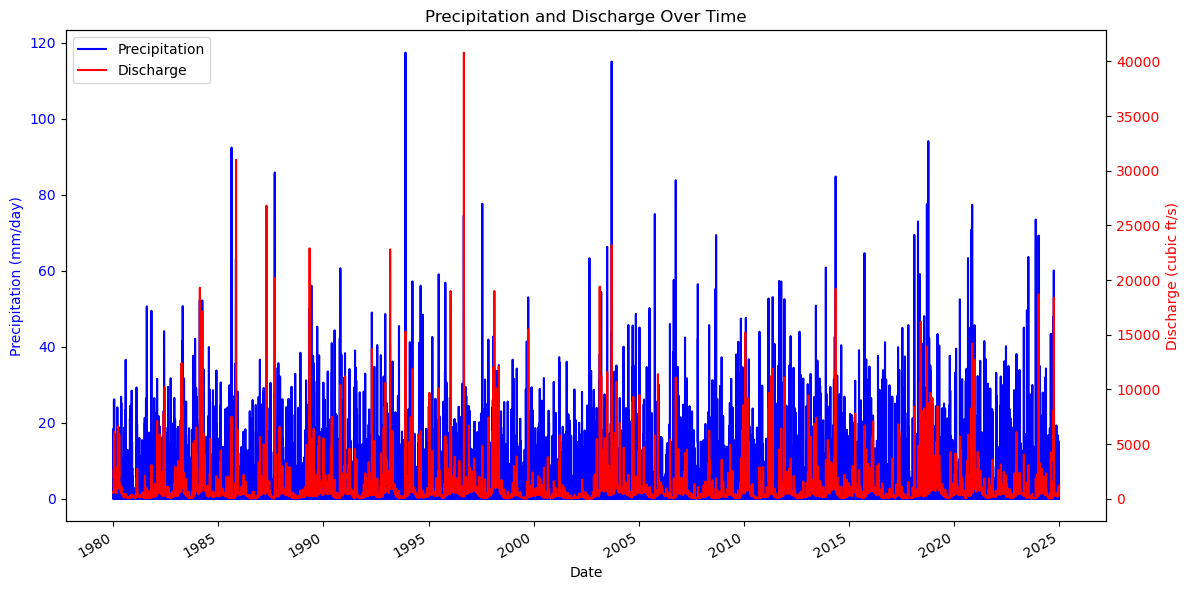

In [52]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot precipitation on left y-axis
ax1.plot(df.index, df['precipitation'], 'b-', label='Precipitation')
ax1.set_xlabel('Date')
ax1.set_ylabel('Precipitation (mm/day)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Create second y-axis
ax2 = ax1.twinx()
ax2.plot(df.index, df['discharge'], 'r-', label='Discharge')
ax2.set_ylabel('Discharge (cubic ft/s)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Title and formatting
plt.title('Precipitation and Discharge Over Time')
fig.autofmt_xdate()  # Rotate date labels

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

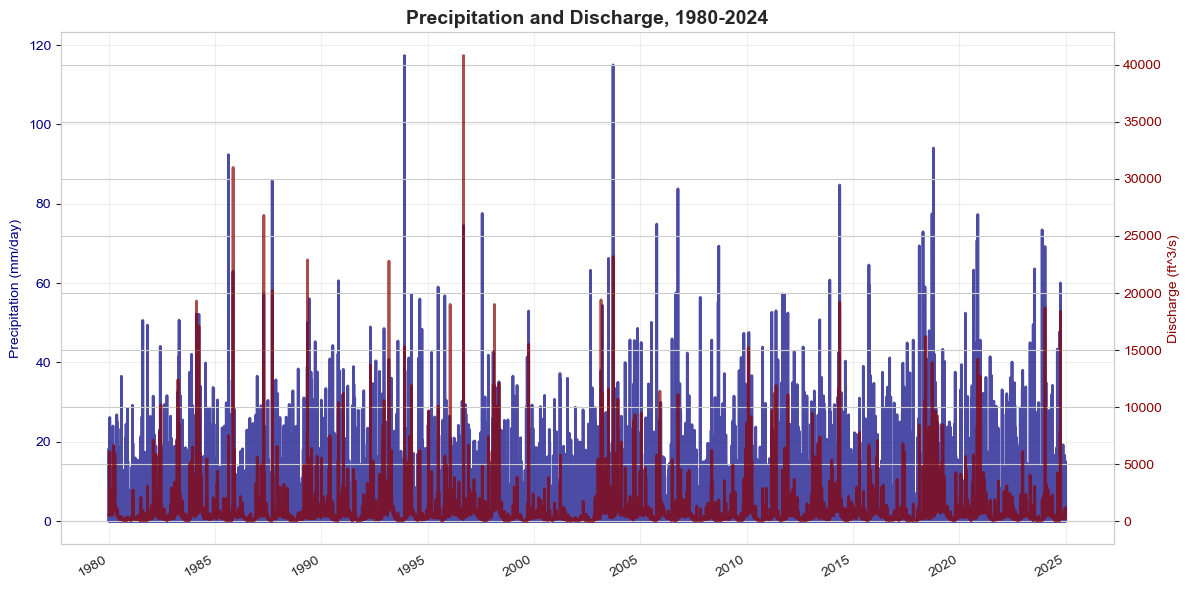

In [60]:
# Set style
sns.set_style("whitegrid")

fig, ax1 = plt.subplots(figsize=(12, 6))

# Precipitation (bars)
ax1.plot(df.index, df['precipitation'], color='navy', linewidth=2, alpha=0.7, label='Precipitation')
ax1.set_ylabel('Precipitation (mm/day)', color='navy')
ax1.tick_params(axis='y', labelcolor='navy')

# Discharge (line)
ax2 = ax1.twinx()
ax2.plot(df.index, df['discharge'], color='darkred', linewidth=2, alpha=0.7, label='Discharge')
ax2.set_ylabel('Discharge (ft^3/s)', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

plt.title('Precipitation and Discharge, 1980-2024', fontsize=14, fontweight='bold')
fig.autofmt_xdate()

# Add grid only for left axis
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [63]:
df.to_csv('merged_data.csv', index=True)

In [65]:
foo = pd.read_csv('merged_data.csv')
foo.set_index('date', inplace=True)
foo.head()

,discharge,precipitation
date,,
1980-01-01,561.0,0.00
1980-01-02,554.0,0.00
1980-01-03,536.0,0.00
1980-01-04,530.0,18.33
1980-01-05,599.0,10.38


In [54]:
import geopandas as gpd
gdf = gpd.read_file('national_shapefile_obs.shp')
print(gdf.columns.tolist())

['GaugeLID', 'Status', 'Location', 'Latitude', 'Longitude', 'Waterbody', 'State', 'Observed', 'ObsTime', 'Units', 'Action', 'Flood', 'Moderate', 'Major', 'LowThresh', 'LowThreshU', 'WFO', 'HDatum', 'PEDTS', 'SecValue', 'SecUnit', 'URL', 'geometry']


In [25]:
gdf[gdf['Location'].str.contains('Palmyra', case=False, na=False)].T

,8424,9140
GaugeLID,PALM7,PYAV2
Status,no_flooding,no_flooding
Location,Palmyra,Palmyra
Latitude,39.816944,37.857778
Longitude,-91.546111,-78.266111
Waterbody,North River (MO),Rivanna River
State,MO,VA
Observed,4.5,2.63
ObsTime,2026-04-24 20:30:00,2026-04-24 20:35:00
Units,ft,ft


In [55]:
station = gdf[gdf['GaugeLID'] == 'PYAV2']

thresholds = {
    'action_stage_ft':   float(station['Action'].values[0]),
    'flood_stage_ft':    float(station['Flood'].values[0]),
    'moderate_stage_ft': float(station['Moderate'].values[0]),
    'major_stage_ft':    float(station['Major'].values[0]),
}

for name, value in thresholds.items():
    print(f"{name}: {value:.2f} ft")

action_stage_ft: 15.00 ft
flood_stage_ft: 17.00 ft
moderate_stage_ft: 25.00 ft
major_stage_ft: 32.00 ft


In [56]:
def assign_flood_risk(gage_height, thresholds):
    if gage_height >= thresholds['major_stage_ft']:
        return 4  # Major flood
    elif gage_height >= thresholds['moderate_stage_ft']:
        return 3  # Moderate flood
    elif gage_height >= thresholds['flood_stage_ft']:
        return 2  # Flood
    elif gage_height >= thresholds['action_stage_ft']:
        return 1  # Action
    else:
        return 0  # Normal

In [39]:
df = pd.read_csv('merged_data.csv')
df.tail()

,date,discharge,precipitation
16431,2024-12-26,296.0,0.00
16432,2024-12-27,281.0,6.11
16433,2024-12-28,334.0,15.02
16434,2024-12-29,1010.0,2.33
16435,2024-12-30,1210.0,0.00


In [42]:
df.columns

Index(['date', 'discharge', 'precipitation'], dtype='object')

In [36]:
gage_daily.tail()

,date,gage_height_ft
6285,2024-12-26,3.096076
6286,2024-12-27,3.068507
6287,2024-12-28,3.093507
6288,2024-12-29,3.835556
6289,2024-12-30,4.390000


In [40]:
foo = df.merge(gage_daily, on='date')

In [45]:
df['date'] = pd.to_datetime(df['date'])
gage_daily['date'] = pd.to_datetime(gage_daily['date'])

merged = df.merge(gage_daily, on='date')

In [48]:
merged = merged.rename(columns={'gage_height_ft': 'gage_height'})

In [49]:
merged.head()

,date,discharge,precipitation,gage_height
0,2007-10-01,37.9,0.0,2.151711
1,2007-10-02,37.1,0.0,2.146250
2,2007-10-03,36.4,0.0,2.140521
3,2007-10-04,37.6,0.0,2.150000
4,2007-10-05,38.1,0.0,2.150937


In [57]:
merged['flood_risk'] = merged['gage_height'].apply(
    lambda x: assign_flood_risk(x, thresholds)
)

# Check the class distribution
print(merged['flood_risk'].value_counts().sort_index())

flood_risk
0    6274
1       5
2      11
Name: count, dtype: int64


In [58]:
merged.to_csv('merged_with_gage.csv')

In [60]:
foo = pd.read_csv('merged_with_gage.csv', index_col='Unnamed: 0')
foo.head()

,date,discharge,precipitation,gage_height,flood_risk
0,2007-10-01,37.9,0.0,2.151711,0
1,2007-10-02,37.1,0.0,2.146250,0
2,2007-10-03,36.4,0.0,2.140521,0
3,2007-10-04,37.6,0.0,2.150000,0
4,2007-10-05,38.1,0.0,2.150937,0
